# Learning with Missing Data

## Motivation

So far, parameter learning assumed that the variables required for learning were observed in the dataset.

For complete data,

$$
D=\{x_1,x_2,\ldots,x_N\},
$$

we could directly estimate model parameters using methods such as maximum likelihood or Bayesian parameter learning.

In practice, datasets are often incomplete.

For example, a robotics dataset may contain

| Time | GPS | LiDAR | Velocity |
|---|---|---|---|
| $t_1$ | observed | observed | observed |
| $t_2$ | missing | observed | observed |
| $t_3$ | observed | missing | observed |
| $t_4$ | missing | missing | observed |

Simply removing every incomplete observation may discard a significant amount of useful information.

The goal is therefore to learn model parameters while accounting for the uncertainty introduced by missing observations.

## Observed and Missing Data

We divide the dataset into two conceptual parts:

$$
D_{\text{obs}}
$$

for the values that were observed, and

$$
D_{\text{mis}}
$$

for the values that are missing.

The complete dataset would therefore be

$$
D=
(D_{\text{obs}},D_{\text{mis}}).
$$

If all values were known, parameter learning could proceed normally.

However, $D_{\text{mis}}$ is unknown.

Therefore, learning with missing data involves reasoning about both

$$
\boxed{
\text{Unknown Model Parameters}
}
$$

and

$$
\boxed{
\text{Unknown Data Values}.
}
$$

## Why Not Discard Incomplete Observations?

A simple solution is to remove every observation containing a missing value.

Consider

| $A$ | $B$ | $C$ |
|---|---|---|
| 1 | 1 | 0 |
| ? | 1 | 1 |
| 1 | ? | ? |
| ? | ? | ? |

Only the first observation is complete.

Removing incomplete observations would therefore reduce four observations to only one.

This can waste useful information because an incomplete observation may still contain valuable observed variables.

Instead of immediately discarding incomplete data, we would like to use the available observations to reason about the missing values.

## Missing Data as an Inference Problem

Suppose we want to learn parameters $\theta$ using only the observed data:

$$
p(\theta\mid D_{\text{obs}}).
$$

The missing data is unknown, so it must be marginalized out.

For discrete missing variables,

$$
\boxed{
p(\theta\mid D_{\text{obs}})=
\sum_{D_{\text{mis}}}
p(\theta,D_{\text{mis}}\mid D_{\text{obs}})
}
$$

or equivalently,

$$
p(\theta\mid D_{\text{obs}})=
\sum_{D_{\text{mis}}}
p(\theta\mid D_{\text{obs}},D_{\text{mis}})
p(D_{\text{mis}}\mid D_{\text{obs}}).
$$

For continuous missing variables, the sum becomes an integral:

$$
p(\theta\mid D_{\text{obs}})=
\int
p(\theta\mid D_{\text{obs}},D_{\text{mis}})
p(D_{\text{mis}}\mid D_{\text{obs}})
\,dD_{\text{mis}}.
$$

Therefore, learning with missing data is closely connected to probabilistic inference.

The missing values behave like hidden variables that must be inferred or marginalized before learning the model parameters.

```text
Inference
────────────────────────────
Observed variables
        +
Hidden variables
        ↓
Marginalize hidden variables
        ↓
Distribution over query


Learning with Missing Data
────────────────────────────
Observed data
        +
Missing data
        ↓
Marginalize / infer missing data
        ↓
Learn model parameters

## Why Is Learning with Missing Data Difficult?

In principle, we could consider every possible completion of the missing data.

For example, suppose three binary values are missing:

$$
D_{\text{mis}}=
(A,B,C).
$$

Each variable can take two values, so there are

$$
2^3=8
$$

possible completions.

With $k$ missing binary values, the number of possible completions becomes

$$
2^k.
$$

For many missing variables, explicitly enumerating all possible completions becomes computationally expensive.

For continuous variables, there may even be infinitely many possible values.

Therefore, practical methods usually avoid explicitly considering every possible completion of the missing dataset.

## Missingness Assumption

The methods considered here assume that the missing data mechanism does not itself reveal unmodeled information about the missing value once the relevant observed variables are taken into account.

This assumption is commonly referred to as **Missing At Random (MAR)**.

However, missing sensor measurements are not always random.

Consider a radar measuring the distance to a target.

A measurement may disappear because the target is beyond the sensing range.

In this situation,

$$
\text{measurement missing}
$$

itself provides information about the likely distance of the target.

The missingness mechanism must then be modeled explicitly; otherwise parameter estimates may become biased.

For this notebook, we assume that the missing-data mechanism is compatible with the methods being used.

## Approaches to Learning with Missing Data

We will consider two general approaches.

### 1. Data Imputation

Estimate values for the missing entries:

$$
D_{\text{mis}}
\rightarrow
\hat{D}_{\text{mis}}.
$$

Then learn the parameters using the completed dataset:

$$
(D_{\text{obs}},\hat{D}_{\text{mis}})
\rightarrow
\hat{\theta}.
$$

### 2. Expectation-Maximization

Instead of completing the data once, repeatedly alternate between:

1. reasoning about the missing information using the current model, and
2. updating the model parameters using that inferred information.

Conceptually,

$$
\boxed{
\theta^{(0)}
\rightarrow
\text{Infer Missing Information}
\rightarrow
\theta^{(1)}
\rightarrow
\text{Infer Again}
\rightarrow
\theta^{(2)}
\rightarrow\cdots
}
$$

We first study data imputation before introducing the iterative Expectation-Maximization algorithm.

## Data Imputation

Data imputation replaces missing entries with estimated values.

Ideally, we would infer the most probable missing values given the observed data:

$$
\boxed{
\hat{D}_{\text{mis}}=
\arg\max_{D_{\text{mis}}}
p(D_{\text{mis}}\mid D_{\text{obs}})
}
$$

Once the missing values have been estimated, we obtain an approximately completed dataset:

$$
\hat D=
(D_{\text{obs}},\hat D_{\text{mis}}).
$$

We can then apply the parameter-learning methods introduced earlier:

$$
\boxed{
\text{Incomplete Data}
\rightarrow
\text{Imputation}
\rightarrow
\text{Completed Data}
\rightarrow
\text{Parameter Learning}
}
$$

The quality of the learned model therefore depends strongly on how the missing values are imputed.

### Marginal Mode Imputation

For discrete variables, a simple approach is to replace missing values with the most frequently observed value of that variable.

For example, suppose

$$
A =
[1,\;1,\;0,\;?,\;1,\;?].
$$

Among the observed values,

$$
1
$$

occurs most frequently.

Therefore,

$$
\text{mode}(A)=1,
$$

and the missing values are replaced by

$$
A =
[1,\;1,\;0,\;1,\;1,\;1].
$$

This method is simple, but it considers each variable independently and ignores relationships between variables.

#### Mean Imputation

For a continuous variable, exact duplicate values may be rare, making the marginal mode less useful.

A common simple alternative is to replace missing values using the mean of the observed values.

For observations

$$
x_1,\ldots,x_m,
$$

the observed mean is

$$
\bar{x}_{\text{obs}}=
\frac{1}{m}
\sum_{i=1}^{m}x_i.
$$

Every missing entry is then replaced by

$$
\boxed{
x_{\text{missing}}
\leftarrow
\bar{x}_{\text{obs}}
}
$$

This produces a complete dataset that can subsequently be used for parameter learning.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

robot_missing = pd.read_csv(
    "../Datasets/DecisionMakingDatasets/robotics/robot_sensor_missing.csv"
)

robot_missing.head()

,time_s,true_x_m,true_y_m,true_velocity_mps,true_heading_rad,gps_x_m,gps_y_m,lidar_x_m,lidar_y_m,velocity_measurement_mps,heading_measurement_rad,gps_error_x_m,gps_error_y_m,lidar_error_x_m,lidar_error_y_m
0,0.0,0.000000,0.000000,1.280000,0.040000,0.389171,-0.116192,-0.186955,0.000243,1.368620,0.057620,0.389171,-0.116192,-0.186955,0.000243
1,0.1,0.127898,0.005119,1.284499,0.041800,-0.127170,0.305739,0.147994,0.067447,1.211959,0.055796,-0.255068,0.300621,0.020097,0.062329
2,0.2,0.256235,0.010486,1.288994,0.043599,NaN,NaN,0.495614,0.418710,1.165425,0.037359,0.027616,0.149763,0.239378,0.408224
3,0.3,0.385012,0.016104,1.293484,0.045397,-0.059789,0.137527,0.093869,-0.082504,1.349801,0.062646,-0.444801,0.121423,-0.291144,-0.098608
4,0.4,0.514227,0.021974,1.297968,0.047194,0.915233,0.474460,0.072914,0.398295,1.263833,0.063715,0.401005,0.452486,-0.441314,0.376320


In [3]:
robot_missing.isna().sum()

time_s                       0
true_x_m                     0
true_y_m                     0
true_velocity_mps            0
true_heading_rad             0
gps_x_m                     60
gps_y_m                     60
lidar_x_m                   40
lidar_y_m                   40
velocity_measurement_mps    32
heading_measurement_rad      0
gps_error_x_m                0
gps_error_y_m                0
lidar_error_x_m              0
lidar_error_y_m              0
dtype: int64

In [4]:
robot_mean_imputed = (
    robot_missing.copy()
)

numeric_columns = (
    robot_mean_imputed
    .select_dtypes(include=np.number)
    .columns
)

for column in numeric_columns:

    mean_value = (
        robot_mean_imputed[column]
        .mean()
    )

    robot_mean_imputed[column] = (
        robot_mean_imputed[column]
        .fillna(mean_value)
    )

In [5]:
robot_mean_imputed.isna().sum()

time_s                      0
true_x_m                    0
true_y_m                    0
true_velocity_mps           0
true_heading_rad            0
gps_x_m                     0
gps_y_m                     0
lidar_x_m                   0
lidar_y_m                   0
velocity_measurement_mps    0
heading_measurement_rad     0
gps_error_x_m               0
gps_error_y_m               0
lidar_error_x_m             0
lidar_error_y_m             0
dtype: int64

#### Limitation of Marginal Imputation

Mean and mode imputation consider each variable independently.

Suppose two variables $X$ and $Y$ are strongly correlated.

If we observe

$$
X=10
$$

but $Y$ is missing, replacing $Y$ with its global mean ignores the information provided by $X$.

For example, if the data approximately follows

$$
Y\approx2X,
$$

then observing

$$
X=10
$$

suggests that

$$
Y\approx20.
$$

Replacing the missing value with the global mean may therefore produce an implausible pair

$$
(X,Y).
$$

The problem is that marginal imputation uses

$$
p(Y)
$$

instead of exploiting the conditional relationship

$$
\boxed{
p(Y\mid X).
}
$$

### Nearest-Neighbor Imputation

Nearest-neighbor imputation uses other observations that are similar in the variables that are available.

Suppose an observation contains

$$
(X=x,\;Y=?).
$$

We search the dataset for another observation whose observed $X$ value is close to $x$:

$$j^*=
\arg\min_j
d(x,x_j).
$$

The missing value can then be replaced using the corresponding value

$$
Y_{j^*}.
$$

Unlike marginal mean or mode imputation, nearest-neighbor imputation uses relationships between variables present in the dataset.

### Probabilistic Imputation

Mean and nearest-neighbor imputation produce missing values using simple rules.

A more principled approach is to build a probabilistic model of the variables and infer the missing value conditioned on the observed values.

For an incomplete observation containing

$$
D_{\text{obs}}
$$

and

$$
D_{\text{mis}},
$$

we compute

$$
\boxed{
p(D_{\text{mis}}\mid D_{\text{obs}})
}
$$

using probabilistic inference.

The missing value can then be imputed using this conditional distribution.

Two possibilities are:

1. **Posterior mode**

$$
\hat D_{\text{mis}}=
\arg\max_{D_{\text{mis}}}
p(D_{\text{mis}}\mid D_{\text{obs}})
$$

2. **Posterior sampling**

$$
\hat D_{\text{mis}}
\sim
p(D_{\text{mis}}\mid D_{\text{obs}}).
$$

#### Gaussian Probabilistic Imputation

Suppose

$$
\begin{bmatrix}
X\\
Y
\end{bmatrix}
\sim
\mathcal N
\left(
\begin{bmatrix}
\mu_X\\
\mu_Y
\end{bmatrix},
\begin{bmatrix}
\Sigma_{XX} & \Sigma_{XY}\\
\Sigma_{YX} & \Sigma_{YY}
\end{bmatrix}
\right).
$$

If $X=x$ is observed while $Y$ is missing, then

$$
Y\mid X=x
$$

is Gaussian with conditional mean

$$
\boxed{
\mu_{Y\mid X}=
\mu_Y
+
\Sigma_{YX}
\Sigma_{XX}^{-1}
(x-\mu_X)
}
$$

and conditional covariance

$$
\boxed{
\Sigma_{Y\mid X}=
\Sigma_{YY}-
\Sigma_{YX}
\Sigma_{XX}^{-1}
\Sigma_{XY}.
}
$$

The conditional distribution therefore uses the relationship between the observed and missing variables to predict a plausible missing value.

In [6]:
rng = np.random.default_rng(42)

x_data = rng.normal(
    loc=0.0,
    scale=2.0,
    size=200,
)

y_data = (
    2.0 * x_data
    + rng.normal(
        loc=0.0,
        scale=1.0,
        size=200,
    )
)

complete_data = np.column_stack([
    x_data,
    y_data,
])

In [7]:
mu = np.mean(
    complete_data,
    axis=0,
)

covariance = np.cov(
    complete_data,
    rowvar=False,
    ddof=0,
)

print("Mean:")
print(mu)

print("\nCovariance:")
print(covariance)

Mean:
[-0.06090145 -0.10172528]

Covariance:
[[ 3.09566672  6.06567307]
 [ 6.06567307 12.91421863]]


In [8]:
x_observed = 3.0

In [9]:
mu_x = mu[0]
mu_y = mu[1]

sigma_xx = covariance[0, 0]
sigma_xy = covariance[0, 1]
sigma_yx = covariance[1, 0]
sigma_yy = covariance[1, 1]

conditional_mean = (
    mu_y
    + sigma_yx
    / sigma_xx
    * (x_observed - mu_x)
)

conditional_variance = (
    sigma_yy
    - sigma_yx
    / sigma_xx
    * sigma_xy
)

print(
    f"Conditional mean: "
    f"{conditional_mean:.3f}"
)

print(
    f"Conditional variance: "
    f"{conditional_variance:.3f}"
)

Conditional mean: 5.896
Conditional variance: 1.029


In [10]:
marginal_imputation = mu_y

posterior_imputation = (
    conditional_mean
)

print(
    "Marginal mean imputation: "
    f"{marginal_imputation:.3f}"
)

print(
    "Posterior mean/mode: "
    f"{posterior_imputation:.3f}"
)

Marginal mean imputation: -0.102
Posterior mean/mode: 5.896


In [11]:
posterior_sample = rng.normal(
    loc=conditional_mean,
    scale=np.sqrt(
        conditional_variance
    ),
)

print(
    f"Posterior sample: "
    f"{posterior_sample:.3f}"
)

Posterior sample: 5.714


### Limitation of One-Shot Imputation

Probabilistic imputation can exploit relationships between variables through

$$
p(D_{\text{mis}}\mid D_{\text{obs}}).
$$

However, there is still an important problem.

To compute this conditional distribution, we need a probabilistic model with known or estimated parameters

$$
\theta.
$$

But those parameters are exactly what we are trying to learn from the incomplete dataset.

This creates a circular dependency:

$$
\boxed{
\text{Need }\theta
\rightarrow
\text{Infer Missing Data}
}
$$

but also

$$
\boxed{
\text{Need Missing Data}
\rightarrow
\text{Estimate }\theta.
}
$$

This motivates an iterative approach:

1. start with an initial estimate of $\theta$,
2. infer the missing information,
3. improve $\theta$ using that inferred information,
4. repeat.

This is the central idea behind **Expectation-Maximization**.

## Expectation-Maximization

Expectation-Maximization (EM) is an iterative method for parameter learning when some variables are missing or unobserved.

The difficulty is that:

$$
\text{we need the model parameters } \theta
$$

to reason about the missing variables, but

$$
\text{we need information about the missing variables}
$$

to estimate the model parameters.

EM resolves this circular dependency by alternating between two steps:

$$
\boxed{
\text{Expectation Step (E-step)}
\leftrightarrow
\text{Maximization Step (M-step)}
}
$$

Starting from an initial parameter estimate

$$
\theta^{(0)},
$$

the two steps are repeated until the parameter estimates converge.

### Intuition

The EM procedure can be viewed as

```text
Initial Parameters θ⁽⁰⁾
          │
          ↓
       E-Step
          │
          ↓
Use current model to infer
the missing / latent information
          │
          ↓
       M-Step
          │
          ↓
Use that inferred information
to re-estimate the parameters
          │
          ↓
     New Parameters θ⁽¹⁾
          │
          └──────────────→ Repeat

### Expectation Step

Suppose

$$
D_{\text{obs}}
$$

is observed and

$$
D_{\text{mis}}
$$

is missing.

At iteration $t$, we currently have parameter estimates

$$
\theta^{(t)}.
$$

The E-step uses these parameters to compute a probability distribution over the missing data:

$$
\boxed{
p(
D_{\text{mis}}
\mid
D_{\text{obs}},
\theta^{(t)}
)
}
$$

Rather than necessarily choosing one value for the missing data, EM uses the probability of the possible completions.

Therefore, uncertain completions contribute according to how plausible they are under the current model.

### Maximization Step

After the E-step, we have probabilistic information about the missing variables.

The M-step uses this information to update the model parameters.

Conceptually,

$$
\boxed{
\theta^{(t+1)}=
\arg\max_\theta
\text{Expected Complete-Data Log-Likelihood}
}
$$

The expectation is taken using the distribution over the missing variables obtained during the E-step.

The new parameters

$$
\theta^{(t+1)}
$$

are then used in the next E-step.

Thus,

$$
\boxed{
\text{E-step}
\rightarrow
\text{infer missing information}
}
$$

$$
\boxed{
\text{M-step}
\rightarrow
\text{re-estimate model parameters}
}
$$

### EM Objective

Let

$$
Z
$$

represent the missing or latent variables and let

$$
X
$$

represent the observed variables.

At iteration $t$, the E-step constructs

$$
\boxed{
Q(\theta,\theta^{(t)})=
\mathbb{E}_{Z\mid X,\theta^{(t)}}
\left[
\log p(X,Z\mid\theta)
\right].
}
$$

This is the expected log-likelihood of the **complete data**, where the expectation accounts for uncertainty about $Z$.

The M-step then computes

$$
\boxed{
\theta^{(t+1)}=
\arg\max_\theta
Q(\theta,\theta^{(t)}).
}
$$

Therefore, EM repeatedly alternates between

$$
\boxed{
\text{Expectation over hidden variables}
}
$$

and

$$
\boxed{
\text{Maximization over model parameters}.
}
$$

### Why "Expectation-Maximization"?

The name describes the two operations performed during every iteration.

#### Expectation

Compute expectations over the missing or latent variables using the current model:

$$
p(Z\mid X,\theta^{(t)}).
$$

#### Maximization

Find new parameters that maximize the expected complete-data log-likelihood:

$$
\theta^{(t+1)}=
\arg\max_\theta
Q(\theta,\theta^{(t)}).
$$

Hence,

$$
\boxed{
\text{Expectation}+\text{Maximization}=
\text{EM}
}
$$

### Expectation-Maximization for Gaussian Mixture Models

Suppose the observed data appears to contain multiple groups.

Instead of representing the data using one Gaussian, we assume that it was generated by a mixture of $K$ Gaussian distributions:

$$
p(x)=
\sum_{k=1}^{K}
\pi_k
\mathcal{N}(x;\mu_k,\sigma_k^2),
$$

where

$$
\pi_k
$$

is the probability of selecting component $k$,

$$
\mu_k
$$

is its mean, and

$$
\sigma_k^2
$$

is its variance.

The mixture weights satisfy

$$
\sum_{k=1}^{K}\pi_k=1.
$$

The complete parameter set is therefore

$$
\theta=
\{
\pi_k,\mu_k,\sigma_k^2
\}_{k=1}^{K}.
$$

#### Latent Component Variable

Introduce a latent categorical variable

$$
Z\in\{1,\ldots,K\}.
$$

The variable $Z$ indicates which Gaussian component generated an observation.

The generative model is

$$
Z\sim\text{Categorical}(\pi_1,\ldots,\pi_K),
$$

followed by

$$
X\mid Z=k
\sim
\mathcal N(\mu_k,\sigma_k^2).
$$

Therefore,

$$
Z\rightarrow X.
$$

We observe $X$, but the component assignment $Z$ is hidden.

If $Z$ were known, parameter learning would be straightforward: we could separate the observations according to their component and estimate the Gaussian parameters using MLE.

The difficulty is precisely that $Z$ is missing.

### E-Step — Component Responsibilities

At iteration $t$, suppose the current parameters are

$$
\pi_k^{(t)},
\qquad
\mu_k^{(t)},
\qquad
\sigma_k^{2(t)}.
$$

For every observation $x_i$, compute

$$
\gamma_{ik}=
P(Z_i=k\mid x_i,\theta^{(t)}).
$$

Using Bayes' rule,

$$
\boxed{
\gamma_{ik}=
\frac{
\pi_k
\mathcal N(x_i;\mu_k,\sigma_k^2)
}{
\sum_{j=1}^{K}
\pi_j
\mathcal N(x_i;\mu_j,\sigma_j^2)
}
}
$$

The value

$$
\gamma_{ik}
$$

is called the **responsibility** of component $k$ for observation $x_i$.

### M-Step — Update Model Parameters

First compute the effective number of observations assigned to component $k$:

$$
\boxed{
N_k=
\sum_{i=1}^{N}
\gamma_{ik}.
}
$$

Unlike ordinary counts, $N_k$ can be fractional because observations contribute probabilistically to different components.

#### Mixture Weight Update

The new mixture weight is

$$
\boxed{
\pi_k^{(t+1)}=
\frac{N_k}{N}.
}
$$

Therefore, the mixture weight represents the fraction of the dataset effectively assigned to component $k$.

#### Mean Update

The component mean is updated using a responsibility-weighted average:

$$
\boxed{
\mu_k^{(t+1)}=
\frac{
\sum_{i=1}^{N}
\gamma_{ik}x_i
}{
N_k
}.
}
$$

Observations for which component $k$ has high responsibility contribute more strongly to its mean.

#### Variance Update

The variance of component $k$ is updated as

$$
\boxed{
\sigma_k^{2(t+1)}=
\frac{
\sum_{i=1}^{N}
\gamma_{ik}
(x_i-\mu_k^{(t+1)})^2
}{
N_k
}.
}
$$

Again, this is the Gaussian MLE variance weighted by the component responsibilities.

### One EM Iteration

One complete EM iteration for a Gaussian mixture model is

```text
Current parameters
πₖ, μₖ, σₖ²
      │
      ↓
 ┌──────────┐
 │  E-Step  │
 └──────────┘
      │
      ↓
For every observation xᵢ,
compute

γᵢₖ = P(Zᵢ = k | xᵢ)
      │
      ↓
Responsibilities
      │
      ↓
 ┌──────────┐
 │  M-Step  │
 └──────────┘
      │
      ├──→ Nₖ = Σᵢ γᵢₖ
      │
      ├──→ πₖ = Nₖ / N
      │
      ├──→ μₖ = Σᵢ γᵢₖxᵢ / Nₖ
      │
      └──→ σₖ² = Σᵢ γᵢₖ(xᵢ-μₖ)² / Nₖ
      │
      ↓
New parameters
πₖ, μₖ, σₖ²
      │
      └────────────→ repeat


The main thing I would make sure is clear before coding is this:

**EM is not assigning each observation permanently to one Gaussian.**

It is saying:

$$
x_i
\rightarrow
(\gamma_{i1},\gamma_{i2},\ldots,\gamma_{iK}),
$$

for example,

$$
x_i
\rightarrow
(0.85,0.15).
$$

Those probabilities are then used as **weights in parameter learning**.

So we can summarize the connection to everything we've learned so far as:

$$
\boxed{
\underbrace{\text{Bayesian inference over }Z}_{E\text{-step}}
\quad+\quad
\underbrace{\text{Weighted MLE}}_{M\text{-step}}
\quad=\quad
\text{EM for GMM}
}
$$

Next we can implement these equations from scratch with the same bimodal data from the KDE notebook. That will also let us directly see how two initially poor Gaussian guesses gradually move toward the two data clusters.

### Implementation

#### Generate the Data

In [12]:
rng = np.random.default_rng(42)

group_1 = rng.normal(
    loc=-2.0,
    scale=0.6,
    size=200,
)

group_2 = rng.normal(
    loc=3.0,
    scale=0.8,
    size=200,
)

data = np.concatenate([
    group_1,
    group_2,
])

rng.shuffle(data)

In [13]:
data

array([-1.89005934, -2.71750379, -1.62122706,  2.73243506, -2.22904274,
        3.29468529, -2.10771153, -2.38385092,  3.25319541, -1.73934581,
       -2.62139225, -2.49468873, -1.83937312, -2.22689753, -1.54972928,
       -1.8683705 , -2.12326253,  3.36750862, -1.36041186, -2.21128013,
       -3.00480977,  2.92217072, -2.20093102,  3.41935027, -1.81189169,
        2.81051979,  3.48700918, -2.08447453, -1.47236122,  4.86212248,
       -1.86039427, -1.48521447,  2.809461  , -1.78587736, -1.86878684,
        4.04764055, -1.73235668, -2.11478259,  2.70540083,  3.252484  ,
       -1.61890943,  3.23679519, -0.93924205, -2.25699669,  4.67453465,
       -2.71325783,  2.70246833,  3.9646829 , -2.27299009, -2.86826748,
       -2.18974556, -2.24921436, -2.48776466,  3.05323665,  3.14120994,
        3.33111223,  3.51002705, -2.38332671,  3.62588027,  4.28340349,
       -2.62399046,  2.89294163,  3.28140513,  2.02675188,  1.8263638 ,
        3.92424963,  2.40512942,  3.00914084, -1.67410744,  3.85

#### Gaussian Density

In [23]:
def gaussian_pdf(
    x: np.ndarray,
    mean: float,
    variance: float,
) -> np.ndarray:

    coefficient = (
        1.0
        / np.sqrt(
            2.0 * np.pi * variance
        )
    )

    exponent = (
        -0.5
        * (x - mean) ** 2
        / variance
    )

    return (
        coefficient
        * np.exp(exponent)
    )

#### Initialize the GMM

In [24]:
n_components = 2

weights = np.array([
    0.5,
    0.5,
])

means = np.array([
    -1.0,
    1.0,
])

variances = np.array([
    2.0,
    2.0,
])

#### E-Step

In [25]:
def expectation_step(
    data: np.ndarray,
    weights: np.ndarray,
    means: np.ndarray,
    variances: np.ndarray,
) -> np.ndarray:

    n_samples = len(data)
    n_components = len(weights)

    responsibilities = np.zeros(
        (n_samples, n_components)
    )

    for k in range(n_components):

        responsibilities[:, k] = (
            weights[k]
            * gaussian_pdf(
                data,
                means[k],
                variances[k],
            )
        )

    responsibilities /= (
        responsibilities.sum(
            axis=1,
            keepdims=True,
        )
    )

    return responsibilities

In [27]:
def maximization_step(
    data: np.ndarray,
    responsibilities: np.ndarray,
):

    effective_counts = (
        responsibilities.sum(axis=0)
    )

    weights = (
        effective_counts
        / len(data)
    )

    means = (
        responsibilities.T @ data
        / effective_counts
    )

    variances = np.zeros(
        len(effective_counts)
    )

    for k in range(
        len(effective_counts)
    ):

        difference = (
            data - means[k]
        )

        variances[k] = (
            np.sum(
                responsibilities[:, k]
                * difference**2
            )
            / effective_counts[k]
        )

    return (
        weights,
        means,
        variances,
    )

In [28]:
responsibilities = expectation_step(
    data,
    weights,
    means,
    variances,
)

new_weights, new_means, new_variances = (
    maximization_step(
        data,
        responsibilities,
    )
)

print("Initial means:")
print(means)

print("\nMeans after one EM iteration:")
print(new_means)

Initial means:
[-1.  1.]

Means after one EM iteration:
[-1.76213843  2.474211  ]


In [29]:
for i in range(5):

    print(
        f"x = {data[i]: .3f}  "
        f"responsibilities = "
        f"{responsibilities[i]}"
    )

x = -1.890  responsibilities = [0.8687623 0.1312377]
x = -2.718  responsibilities = [0.93805164 0.06194836]
x = -1.621  responsibilities = [0.83496429 0.16503571]
x =  2.732  responsibilities = [0.06108635 0.93891365]
x = -2.229  responsibilities = [0.90282741 0.09717259]


In [30]:
weights = np.array([
    0.5,
    0.5,
])

means = np.array([
    -1.0,
    1.0,
])

variances = np.array([
    2.0,
    2.0,
])

n_iterations = 30

mean_history = [
    means.copy()
]

for iteration in range(
    n_iterations
):

    # E-step
    responsibilities = (
        expectation_step(
            data,
            weights,
            means,
            variances,
        )
    )

    # M-step
    (
        weights,
        means,
        variances,
    ) = maximization_step(
        data,
        responsibilities,
    )

    mean_history.append(
        means.copy()
    )

In [31]:
print("Mixture weights:")
print(weights)

print("\nMeans:")
print(means)

print("\nStandard deviations:")
print(
    np.sqrt(variances)
)

Mixture weights:
[0.49985974 0.50014026]

Means:
[-2.0187632   3.01514271]

Standard deviations:
[0.52708731 0.81529918]


In [32]:
x = np.linspace(
    data.min() - 2.0,
    data.max() + 2.0,
    1000,
)

component_1 = (
    weights[0]
    * gaussian_pdf(
        x,
        means[0],
        variances[0],
    )
)

component_2 = (
    weights[1]
    * gaussian_pdf(
        x,
        means[1],
        variances[1],
    )
)

mixture_density = (
    component_1
    + component_2
)

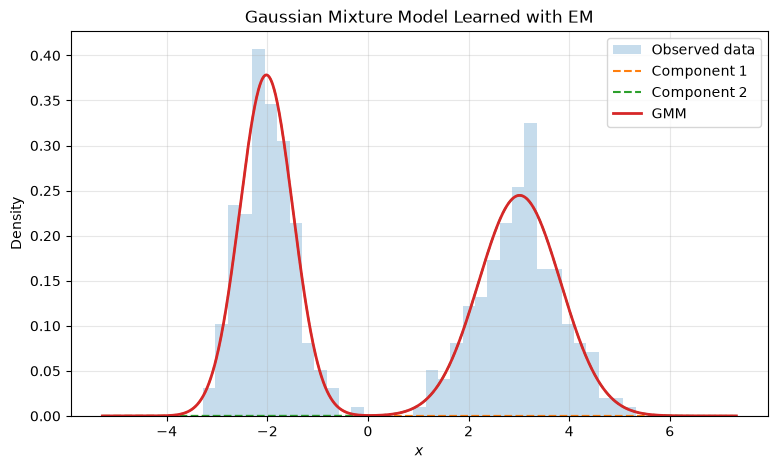

In [33]:
plt.figure(figsize=(9, 5))

plt.hist(
    data,
    bins=35,
    density=True,
    alpha=0.25,
    label="Observed data",
)

plt.plot(
    x,
    component_1,
    linestyle="--",
    label="Component 1",
)

plt.plot(
    x,
    component_2,
    linestyle="--",
    label="Component 2",
)

plt.plot(
    x,
    mixture_density,
    linewidth=2,
    label="GMM",
)

plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title("Gaussian Mixture Model Learned with EM")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

The observations $x_i$ were available to the algorithm, but their component labels

$$
z_i
$$

were never provided.

EM simultaneously inferred the latent component assignments and learned the Gaussian mixture parameters.

During the E-step,

$$
\gamma_{ik}=
P(Z_i=k\mid x_i,\theta^{(t)})
$$

represents the current belief about which component generated each observation.

During the M-step, these probabilities act as weights when estimating

$$
\pi_k,
\qquad
\mu_k,
\qquad
\sigma_k^2.
$$

The updated parameters then change the responsibilities during the next E-step.

Therefore,

$$
\boxed{
\text{Inference}
\rightarrow
\text{Parameter Learning}
\rightarrow
\text{Inference}
\rightarrow
\text{Parameter Learning}
\rightarrow\cdots
}
$$

continues until the parameters converge.

## EM Convergence

For a Gaussian mixture model, the likelihood of an observation is

$$
p(x_i\mid\theta)=
\sum_{k=1}^{K}
\pi_k
\mathcal N(x_i;\mu_k,\sigma_k^2).
$$

For the complete observed dataset,

$$
P(D\mid\theta)=
\prod_{i=1}^{N}
p(x_i\mid\theta).
$$

As with maximum likelihood estimation, it is more convenient to work with the log-likelihood:

$$
\boxed{
\log P(D\mid\theta)=
\sum_{i=1}^{N}
\log
\left[
\sum_{k=1}^{K}
\pi_k
\mathcal N(x_i;\mu_k,\sigma_k^2)
\right]
}
$$

EM iteratively updates the parameters such that the observed-data likelihood does not decrease.

Therefore, the log-likelihood can be used to monitor the progress of the algorithm.

In [34]:
def gmm_log_likelihood(
    data: np.ndarray,
    weights: np.ndarray,
    means: np.ndarray,
    variances: np.ndarray,
) -> float:

    likelihood = np.zeros(
        len(data)
    )

    for k in range(len(weights)):

        likelihood += (
            weights[k]
            * gaussian_pdf(
                data,
                means[k],
                variances[k],
            )
        )

    return np.sum(
        np.log(likelihood)
    )

In [35]:
n_iterations = 30

In [36]:
weights = np.array([
    0.5,
    0.5,
])

means = np.array([
    -1.0,
    1.0,
])

variances = np.array([
    2.0,
    2.0,
])

max_iterations = 100
tolerance = 1e-6

log_likelihood_history = []

for iteration in range(max_iterations):

    # E-step
    responsibilities = (
        expectation_step(
            data,
            weights,
            means,
            variances,
        )
    )

    # M-step
    (
        weights,
        means,
        variances,
    ) = maximization_step(
        data,
        responsibilities,
    )

    log_likelihood = (
        gmm_log_likelihood(
            data,
            weights,
            means,
            variances,
        )
    )

    log_likelihood_history.append(
        log_likelihood
    )

    if iteration > 0:

        improvement = (
            log_likelihood_history[-1]
            - log_likelihood_history[-2]
        )

        if abs(improvement) < tolerance:
            break

In [37]:
print(
    f"Converged after "
    f"{iteration + 1} iterations."
)

print(
    f"Final log-likelihood: "
    f"{log_likelihood:.3f}"
)

Converged after 7 iterations.
Final log-likelihood: -675.717


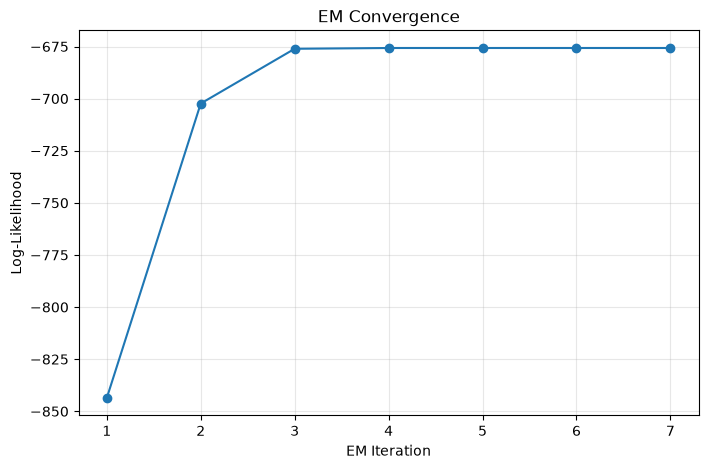

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(
        1,
        len(log_likelihood_history) + 1,
    ),
    log_likelihood_history,
    marker="o",
)

plt.xlabel("EM Iteration")
plt.ylabel("Log-Likelihood")
plt.title("EM Convergence")
plt.grid(alpha=0.3)

plt.show()

### Initialization and Local Optima

EM improves the likelihood iteratively, but it does not generally guarantee convergence to the globally optimal parameter values.

The final solution can depend on the initialization

$$
\theta^{(0)}.
$$

Different initial values may therefore lead to different solutions.

For Gaussian mixture models, practical implementations often run EM several times using different initializations and retain the solution with the highest final log-likelihood.

Therefore,

$$
\boxed{
\text{EM}
\rightarrow
\text{Monotonic Likelihood Improvement}
}
$$

does not imply

$$
\boxed{
\text{EM}
\rightarrow
\text{Guaranteed Global Optimum}.
}
$$

## EM for Missing Continuous Measurements

Consider a multivariate Gaussian model

$$
X \sim \mathcal N(\mu,\Sigma).
$$

Some components of each observation may be missing.

If the dataset were complete, Gaussian MLE would give

$$
\hat{\mu}=
\frac{1}{N}
\sum_{i=1}^{N}x_i
$$

and

$$
\hat{\Sigma}=
\frac{1}{N}
\sum_{i=1}^{N}
(x_i-\hat{\mu})
(x_i-\hat{\mu})^T.
$$

With missing values, these sufficient statistics cannot be computed directly.

EM solves this iteratively:

```text
Initial μ, Σ
     │
     ↓
   E-Step
     │
     ↓
Infer distributions of missing
values conditioned on observed values
     │
     ↓
Compute expected sufficient statistics
     │
     ↓
   M-Step
     │
     ↓
Re-estimate μ and Σ
     │
     └──────────→ Repeat


### E-Step

Using the current parameters, the conditional distribution of the missing variables is

$$
X_m\mid X_o=x_o
\sim
\mathcal N
(
\mu_{m\mid o},
\Sigma_{m\mid o}
),
$$

where

$$
\boxed{
\mu_{m\mid o}=
\mu_m
+
\Sigma_{mo}
\Sigma_{oo}^{-1}
(x_o-\mu_o)
}
$$

and

$$
\boxed{
\Sigma_{m\mid o}=
\Sigma_{mm}-
\Sigma_{mo}
\Sigma_{oo}^{-1}
\Sigma_{om}.
}
$$

Therefore, the E-step is again a Gaussian inference problem.

### Robotics Interpretation

Consider a sensor vector

$$
x_t=
\begin{bmatrix}
x_{\text{GPS}}\\
x_{\text{LiDAR}}\\
v
\end{bmatrix}.
$$

Suppose the GPS measurement is missing while LiDAR and velocity remain available:

$$
x_t=
\begin{bmatrix}
?\\
x_{\text{LiDAR}}\\
v
\end{bmatrix}.
$$

If these variables are statistically related, the current model can compute

$$
p(
x_{\text{GPS}}
\mid
x_{\text{LiDAR}},v
).
$$

The E-step uses this conditional distribution to compute the expected missing information.

The M-step then uses the expected complete-data statistics to update

$$
\mu
\quad\text{and}\quad
\Sigma.
$$

The improved model is then used to perform better inference during the next E-step.

```text
Conceptually

GPS = ?
LiDAR = observed
Velocity = observed
       │
       ↓
Current μ, Σ
       │
       ↓
Gaussian Conditioning
       │
       ↓
p(GPS | LiDAR, Velocity)
       │
       ↓
Expected GPS information
       │
       ↓
Update μ, Σ
       │
       └──────────────→ repeat    

## Missing Data vs Latent Variables

EM can be used when information required for parameter learning is unobserved.

This can happen in different ways.

### Missing Measurement

A variable exists in the dataset but its value is unavailable:

$$
x_i=
[x_1,\;?,\;x_3].
$$

For example, a GPS measurement may be missing.

### Latent Variable

A variable is part of the probabilistic model but is never directly observed.

In a Gaussian mixture model,

$$
Z_i
$$

represents the component that generated observation $x_i$.

We observe

$$
x_i,
$$

but not

$$
z_i.
$$

Both situations lead to the same general problem:

$$
\boxed{
\text{Some information required for learning is unknown.}
}
$$

EM handles this by alternating between inference over the unknown information and parameter estimation.

## Learning with Missing Data — Flowchart

```text
                    Incomplete / Hidden Data
                              │
                ┌─────────────┴─────────────┐
                ↓                           ↓
          Data Imputation                  EM
                │                           │
      ┌─────────┼─────────┐                 ↓
      ↓         ↓         ↓             Initialize θ
 Mean/Mode   Nearest   Probabilistic          │
             Neighbor   Imputation             ↓
                          │                  E-Step
                          ↓                     │
                   p(D_mis | D_obs)             ↓
                                          Infer Missing /
                                          Latent Information
                                                │
                                                ↓
                                             M-Step
                                                │
                                                ↓
                                          Re-estimate θ
                                                │
                                                ↓
                                            Converged?
                                           /         \
                                         No           Yes
                                         │             │
                                         └── E-Step    ↓
                                                   Learned Model


## Final Takeaway

Learning becomes more difficult when some of the information required to estimate the model parameters is unobserved.

Simple imputation replaces missing values with single estimates, but this may ignore relationships between variables or uncertainty about the missing values.

Probabilistic inference instead considers

$$
p(D_{\text{mis}}\mid D_{\text{obs}},\theta).
$$

Expectation-Maximization combines this inference step with parameter learning:

$$
\boxed{
\theta^{(t)}
\xrightarrow{\text{E-step}}
\text{Expected Missing Information}
\xrightarrow{\text{M-step}}
\theta^{(t+1)}.
}
$$

For Gaussian mixture models, the E-step computes component responsibilities and the M-step performs responsibility-weighted maximum likelihood estimation.

More generally, EM provides a bridge between two major ideas developed so far:

$$
\boxed{
\text{Inference}
\longleftrightarrow
\text{Parameter Learning}.
}
$$